# Q7 - Understanding data

### Focus b: descriptive statistics for model selection
In this exercise, we use descriptive statistics to describe generalisability of a model. We have 100 generated data points, where the underlying truth function is a 2nd order polynomial, but gaussian noise is added. We then attempt to fit a 2nd order polynomial 100 times, using 20 sample points for training. The leftover 80 samples are used for testing in each iteration, and we can look at the mean squared error from training and testing for each iteration. Under task 4, we plot the MSE as a line plot and a box plot. Especially from the box plot, we get information such as median MSE, the spread of the MSE, which can tell us a lot about the variance of the model. Small training data subset, therefore high spread on training MSE, high variance. Also large bias, as there is a systemic error on both training and testing. 

Further down, we use statistics to select the complexity of our model. For the same data, we fit a polynomial of varying degree using 20 samples for training, iterating 100 times. The bar plot shows the mean, with whiskers showing one standard deviation. As expected, training MSE goes down with more complex model, but the opposite happens for testing MSE. The model becomes overfitted by the 4th order polynomial, and the best fit is the 2nd order (which is the underlying truth function)

Lastly we attempt to fit a 5th order polynomial to the data, and look at the covariance and correlation of the model parameters. It’s interesting to look at the covariance matrix on the diagonal, where we have the variances. The spread of the first 3 parameters is small to none, but the last parameters have a much larger variance. It therefore depends greatly on the training data what the last 3 parameters are. This is a sign of overfitting, as it starts fitting to the noise instead of the underlying trend. High correlation might also suggest one of the coefficients is redundant.

### Focus c: Noise, outliers and missing data
Wrangling data is an important step between data collection and training your model. You need to understand your data, where you can use different descriptive statistical methods. You also need to understand any noise you have in your data, as well as outliers. You can also have that some of your data is missing. 

In the first part of this exercise (model fitting), we have some generated data with gaussian noise added, and we will attempt to fit a 2nd order polynomial, by iterating 100 times and picking 20/100 random samples for training. We found that the gaussian noise did not affect the models ability to fit the polynomial, but outliers greatly affected this. The gaussian noise is a case of unstructured noise, which we cannot really model for. But the more data we have, the less of an impact it has. The outliers have a much greater impact. They are additive outliers, as they have a much greater magnitude than the rest of the data and are not frequent. This skews the model greatly in our case. Important to know whether the outliers are valid, or if they exist because of noise. We can remove noise by filtering, e.g. by smoothing with gaussian blur. 

In 03-missing_data, we have human poses, where each pose is made up of 25 skeletal joints, so 25 coordinate points for one sample. In some of our samples, we are missing a skeletal joint. See visualisation above task 1. We have different methods for handling these missing values. 
1. Fill with zero, which is like doing nothing. 
2. Fill with mean of that feature
3. linear interpolation. We assume a straight line between two last known points, and interpolate between them, across joints in poses. 

It depends on the data which method is best. We use descriptive statistics to choose. We can look at the mean sequence of poses and the mean pose, and compare with our different methods. Of course, the mean filling method is similar to these, as it filled with these exact values. The interpolation also performs well, but it especially has a hard time on the edge cases when the first or last values of a sequence is missing, as it then just repeats the closest known value. 

Lastly, we use correlation matrices to compare the original true poses to the imputation methods. We can see that for the interpolation method, the relationships between variables are maintained, and it suggests that imputed data does not deviate significantly. We preserve the generel relationships between different joints in the poses. 

# Model selection and descriptive statistics
In this exercise, you are given noisy data and methods to fit polynomial models multiple times to different subsets of the data. Your task is to use descriptive statistics (such as mean, variance, covariance, and correlation) to analyze the performance of these models and reflect on how well they fit the data. You will investigate how
- the models capture the underlying data 
- the fit varies across different subsets of training data
- assess how well the models perform on unseen data.

## Functions and libraries
The cell below contains functions for generating a noisy dataset and fitting a polynomial multiple times to different subsets of the generated data. More specifically:
1. `generate_polynomial(x, coeffs)`
: Generates ground truth data from the underlying function for a polynomial given the coefficients.
2. `add_gaussian_noise(y, mean, variance, num_outliers)`
: Adds Gaussian noise with a specified **mean** and **variance** and a number of outliers (`num_outliers`
) to simulate noisy data.
3. `fit_polynomial(x, y, M, N)`
: Samples  $M$  random points  $(x, y)$ from the dataset and fits an $N$-th order polynomial to the points. The function returns the fitted coefficients and the mean squared error (MSE) of the fit.
4. `iterate_fit(x, y, M, N, K)`
: Performs the polynomial fitting $K$ times, each time sampling  $M$  points  $(x, y)$  and fitting a polynomial of order $N$. The method returns the mean and variance of the MSE fits of each iteration, the mean of the fitted coefficients, and their covariance and correlation matrices.

## Model Fitting

---
**Task 1 (easy): Fitting the models👩‍💻**
1. Run the cells below to create the inputs `x_range`
 and the noisy outputs `y_noisy`

2. Use the `iterate_fit()`
 function to fit a 2nd-order polynomial to the generated inputs and outputs. Fit the model 100 times, sampling 20 points as the training data in each iteration.


---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to generate polynomial values
def generate_polynomial(x, coeffs):
    return np.polyval(coeffs, x)

# Function to add Gaussian noise and outliers
def add_gaussian_noise(y, mean, variance, num_outliers):
    noisy_y = y + np.random.normal(mean, np.sqrt(variance), len(y))
    
    # Add outliers
    outlier_indices = np.random.choice(range(len(noisy_y)), size=num_outliers, replace=False)
    for idx in outlier_indices:
        noisy_y[idx] += 10 * variance  # Adding large variance to simulate outliers
    
    return noisy_y

# Function to sample M points and fit a polynomial of order N
def fit_polynomial(x, y, M, N):
    # Randomly sample M points from the dataset
    indices = np.random.choice(len(x), M, replace=False)
    x_sampled = x[indices]
    y_sampled = y[indices]
    
    # Fit a polynomial of order N to the sampled points
    coeffs = np.polyfit(x_sampled, y_sampled, N)
    fitted_poly = np.poly1d(coeffs)
    
    # Calculate loss (mean squared error)
    y_fitted = fitted_poly(x_sampled)
    mse = np.mean((y_sampled - y_fitted) ** 2)
    
    return mse, coeffs


# Function to iterate K times, fit the model and compute mean/variance of errors and params
def iterate_fit(x, y, M, N, K):
    errors = []
    coeffs_list = []
    
    for _ in range(K):
        mse, coeffs = fit_polynomial(x, y, M, N)
        errors.append(mse)
        coeffs_list.append(coeffs)
    
    # Convert lists to arrays for easier manipulation
    errors = np.array(errors)
    coeffs_array = np.array(coeffs_list)
    
    # Compute statistics
    error_mean = np.mean(errors)
    error_variance = np.var(errors, ddof=1)
    coeffs_mean = np.mean(coeffs_array, axis=0)
    coeffs_covariance = np.cov(coeffs_array, rowvar=False)
    coeffs_correlation = np.corrcoef(coeffs_array, rowvar=False)
    
    return errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation

# Function for plotting, to prepare error bars
def prepare_error_bars(means, variances):
    std = np.sqrt(variances)
    lower_bound = np.maximum(0, np.array(means) - std)
    upper_bound = np.array(means) + std
    return [np.array(means) - lower_bound, upper_bound - np.array(means)]

In [4]:
# Parameters for the dataset
coefficients = [1, -2, 3]  # Coefficients for the polynomial (change as needed)
x_range = np.linspace(-10, 10, 100)  # Range of x values
mean = 0  # Mean for the Gaussian noise
variance = 650  # Variance for the Gaussian noise
num_outliers = 3  # Number of outliers to introduce

# Generate noise-free polynomial dataset
y_clean = generate_polynomial(x_range, coefficients)

# Generate dataset with Gaussian noise and outliers
y_noisy = add_gaussian_noise(y_clean, mean, variance, num_outliers)

# Write your code here
M, N, K = 20, 2, 100
errors, coeffs_array, error_mean, error_variance, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, 20, 2, 100)


---
**Task 2 (medium): Plotting the results👩‍💻💡📽️**
1. Run the cell below to display the fitted polynomial models and the mean fitted polynomial over the noisy data.

2. What does the variability of the fitted polynomials say about the complexity of the underlying function?

3. Repeat the model fitting process with the same parameters as before, but using noisy data with 5 and 15 outliers. 

4. Compare the results of having 0, 5 and 15 outliers. How do the outliers impact the variability of the individual models and the mean fitted polynomial?

5. Repeat the model fitting process with the same parameter as before, but set the number of outliers to 0 and adjust the noise variance to 150 and then to 650. 

6. How is the mean fitted polynomial affected by the increase in the noise variance? Does noise affect the model similarly to outliers? 



---

In [ ]:
# Write your reflections here...
#2. Most of the fitted polynomials fit very well, so the complexity seems to fit
#4. Outliers skew the fitted models a great deal. With 0 outliers, all polynomials fit. 
#   With 5 outliers, the mean fitted polynomial no longer fit, even though a large part of the individual polynomials fit well. Higher variability.
#   With 10 outliers, the mean fitted polynomial is worse, and only a small part of the individual polynomials fit the data.
#6. With 150 noise variance, the mean fitted polynomial still fit well. 
#   So does it for 650, but the individual polynomials are more varied (spread). 
#   Does not affect the model the same as outliers. 
#   The gaussian noise is very symmetric, so it does not affect the model very negatively.

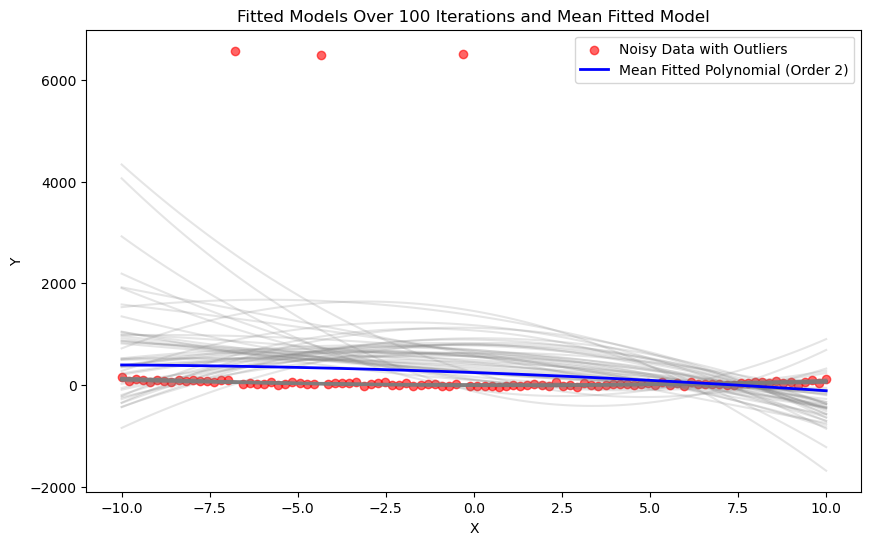

In [6]:
# Plot all fitted models and the mean fitted polynomial
plt.figure(figsize=(10, 6))
plt.scatter(x_range, y_noisy, label='Noisy Data with Outliers', color='red', alpha=0.6)

# Plot all fitted models from the iterations
for i in range(K):
    fitted_poly = np.poly1d(coeffs_array[i])
    plt.plot(x_range, fitted_poly(x_range), color='gray', alpha=0.2)

# Plot the mean fitted polynomial
fitted_mean_poly = np.poly1d(coeffs_mean)
plt.plot(x_range, fitted_mean_poly(x_range), label=f'Mean Fitted Polynomial (Order {N})', color='blue', linewidth=2)

plt.title(f"Fitted Models Over {K} Iterations and Mean Fitted Model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [0]:
# Write your reflection here

## Generalizability

---
**Task 3 (medium): Test set MSE👩‍💻**
The following task will modify the `fit_polynomial()`
 and the `iterate_fit()`
 functions to test the model's performance on unseen data.
1. Modify the `fit_polynomial()`
 function:    - Uncomment the line under `# Comment1`
 to create a test set and read the documentation on  [`np.setdiff1d()`
](https://numpy.org/doc/2.0/reference/generated/numpy.setdiff1d.htmls)

    - Compute `y_fitted_test`
 by applying the polynomial model to the inputs in the test set.
    - Calculate the mean squared error (MSE) for the model’s predictions on the test data and store it in `mse_test`
.


2. Modify the `iterate_fit()`
 function:    - Calculate the mean (`error_mean_test`
) and variance (`error_variance_test`
) of the test errors and let the function return these values. 


3. Generate noisy outputs with the variance of the Gaussian noise set to $100$ and no outliers. 
4. Use the generated data to fit a 2nd-order polynomial using  `iterate_fit()`
. Fit the model 100 times, sampling 20 points in each iteration.


---

In [18]:
# 1.

def fit_polynomial(x, y, M, N):
    # Randomly sample M points from the dataset for training
    indices = np.random.choice(len(x), M, replace=False)
    x_sampled = x[indices]
    y_sampled = y[indices]
    
    # Use the remaining points as the test set
    # Comment1
    test_indices = np.setdiff1d(np.arange(len(x)), indices)
    x_test = x[test_indices]
    y_test = y[test_indices]

    
    # Fit a polynomial of order N to the sampled points
    coeffs = np.polyfit(x_sampled, y_sampled, N)
    fitted_poly = np.poly1d(coeffs)
    
    # Calculate training loss (mean squared error) on the sampled points
    y_fitted_train = fitted_poly(x_sampled)
    mse_train = np.mean((y_sampled - y_fitted_train) ** 2)
    
    # Calculate test loss (mean squared error) on the remaining points (unseen data)
    y_fitted_test = fitted_poly(x_test)
    mse_test = np.mean((y_test - y_fitted_test) ** 2) 

    return mse_train, mse_test, coeffs


# 2. 
def iterate_fit(x, y, M, N, K):
    errors_train = []
    errors_test = []
    coeffs_list = []
    
    for _ in range(K):
        # Get both training and test errors from fit_polynomial
        mse_train, mse_test, coeffs = fit_polynomial(x, y, M, N)
        errors_train.append(mse_train)
        errors_test.append(mse_test)
        coeffs_list.append(coeffs)
    
    # Convert lists to arrays for easier manipulation
    errors_train = np.array(errors_train)
    errors_test = np.array(errors_test)
    coeffs_array = np.array(coeffs_list)
    
    # Compute statistics for training errors
    error_mean_train = np.mean(errors_train)
    error_variance_train = np.var(errors_train, ddof=1)
    
    # Compute statistics for test errors
    error_mean_test = np.mean(errors_test) # replace
    error_variance_test = np.var(errors_test, ddof=1) # replace

    # Compute coefficient statistics
    coeffs_mean = np.mean(coeffs_array, axis=0)
    coeffs_covariance = np.cov(coeffs_array, rowvar=False)
    coeffs_correlation = np.corrcoef(coeffs_array, rowvar=False)
    
    return (errors_train, errors_test, coeffs_array, 
            error_mean_train, error_variance_train, 
            error_mean_test, error_variance_test, 
            coeffs_mean, coeffs_covariance, coeffs_correlation)
    
# Set parameters for sampling and fitting
M = 20  # Number of samples to use
N = 2   # Order of the polynomial to fit
K = 100  # Number of iterations

# 3.

# Generate noisy outputs
# Write your solution here
y_noisy = add_gaussian_noise(y_clean, mean, 100, 0) 

# 4.  

# Apply the updated iterate_fit(function)
# Write your code here
errors_train, errors_test, coeffs_array, error_mean_train, error_variance_train, error_mean_test, error_variance_test,coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)


---
**Task 4 (medium): Evaluation on test set💡📽️**
Run the cell below to plot the training and testing error values for each iteration (line plot on top), along with the mean errors for both the training and testing sets (box plot on bottom). Reflect on: 
1. How does the trend of the training MSE (as seen in the line plot) compare to the trend of the test MSE over the 100 iterations?
2. What role does the variance in the test MSE play in understanding the model’s robustness on unseen data?
3. Are there any clear outliers in the boxplot for either the mean training or test MSE? How might outliers affect your understanding of the model’s performance?
4. From the boxplot, do the distributions of training and test MSE overlap significantly, or are they visibly different? What does this suggest about the generalization capability of the model?
5. Based on the line plot, do any iterations show large fluctuations in the test MSE compared to the training MSE? How does this align with what you observe in the boxplot?
6. Given the boxplot’s visualization of the MSE distributions, do the whiskers (range) for the train MSE extend further than those for the test MSE? What could explain the larger variance in train errors?


**Hint**
Take the size of the training and testing sets into consideration.


---

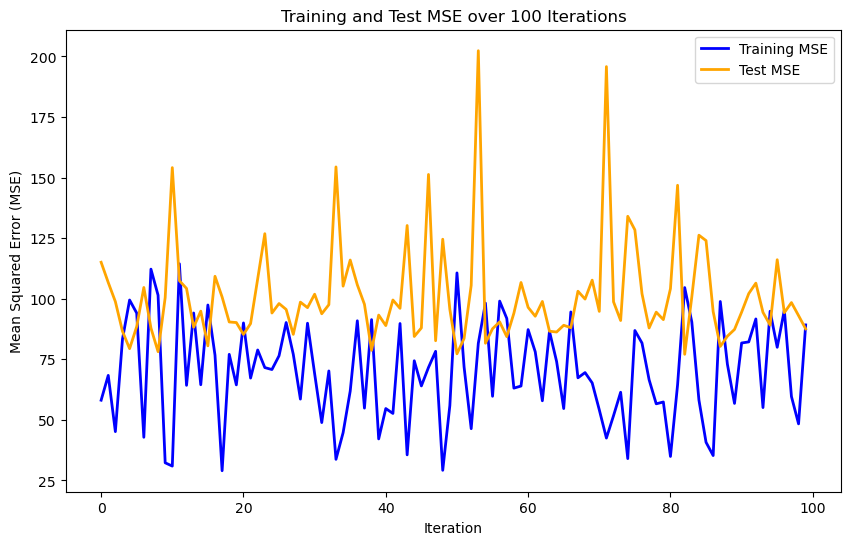

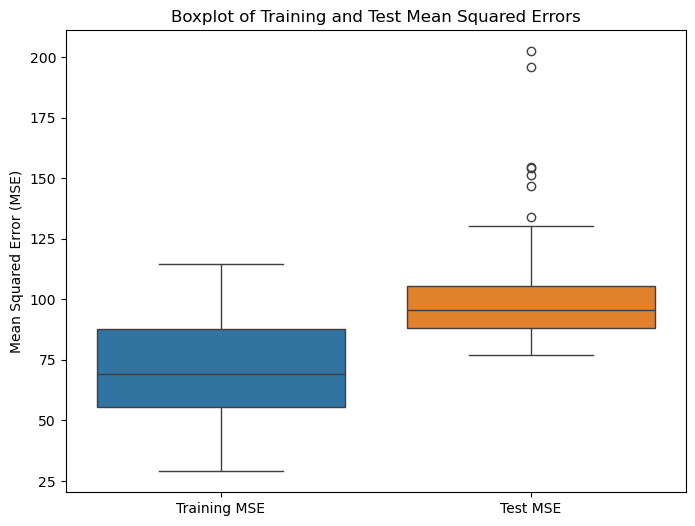

In [19]:
# Plot the training and test MSE over 100 iterations
plt.figure(figsize=(10, 6))
plt.plot(range(K), errors_train, label='Training MSE', color='blue', linewidth=2)
plt.plot(range(K), errors_test, label='Test MSE', color='orange', linewidth=2)
plt.title('Training and Test MSE over 100 Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

# Boxplot of the training and test MSE
plt.figure(figsize=(8, 6))
sns.boxplot(data=[errors_train, errors_test])
plt.xticks([0, 1], ['Training MSE', 'Test MSE'])
plt.title('Boxplot of Training and Test Mean Squared Errors')
plt.ylabel('Mean Squared Error (MSE)')
plt.show()

In [0]:
#Write your reflections here...
#1. The test mse trends higher than the train mse. The spikes of the test mse also seem to be taller. 
#2. if we get high varience in test mse, we can say that the model's ability to generalise is not great. It's not very robust, 
#   and it depends very much on the randomly chosen data if the mse is 100 or 200. It's not very robust. 
#3. The boxplot of the test mse has multiple outliers. 
#   It shows us that for a few iterations, we get a much greater mean squared error than normal. 
#   So the model sometimes predict very wrong on unseen data. 
#4. The boxplots of the training and test mse only overlap a bit. 
#   MSE for 25-75% of iterations do not overlap, so we might say that the model does not generalise well. 
#5. The large spikes in the line plot are the same as the outliers in boxplot. So sometimes we get a test mse of around 200. 
#6. The whiskers of the train mse show a larger range than test mse. So train mse has high variability.  
#   That could be because it can matter a lot what training data is randomly chosen. 
#   Because we have some gaussian noise, the chosen training data points can be difficult to fit a polynomial to, so it will give an error no matter what. 

## Model complexity

---
**Task 5 (medium): Polynomial order👩‍💻💡**
This task experiments with fitting an increasingly more complex model to the data. The cell below performs polynomial fitting for the orders defined in the `degrees`
 array and stores the mean and variance of the training and test errors.
1. Run the cell below to visualize the mean and variance of the training and testing MSEs across different model degrees. How does increasing model complexity impact the training and testing errors?
2. Inspect the graph and identify at which degree does the model seem to overfit? Reflect on how this corresponds to the underlying function.
3. Observe how the model parameters change as the polynomial order increases. Explain the reasons for the observations on the higher-order terms.


---

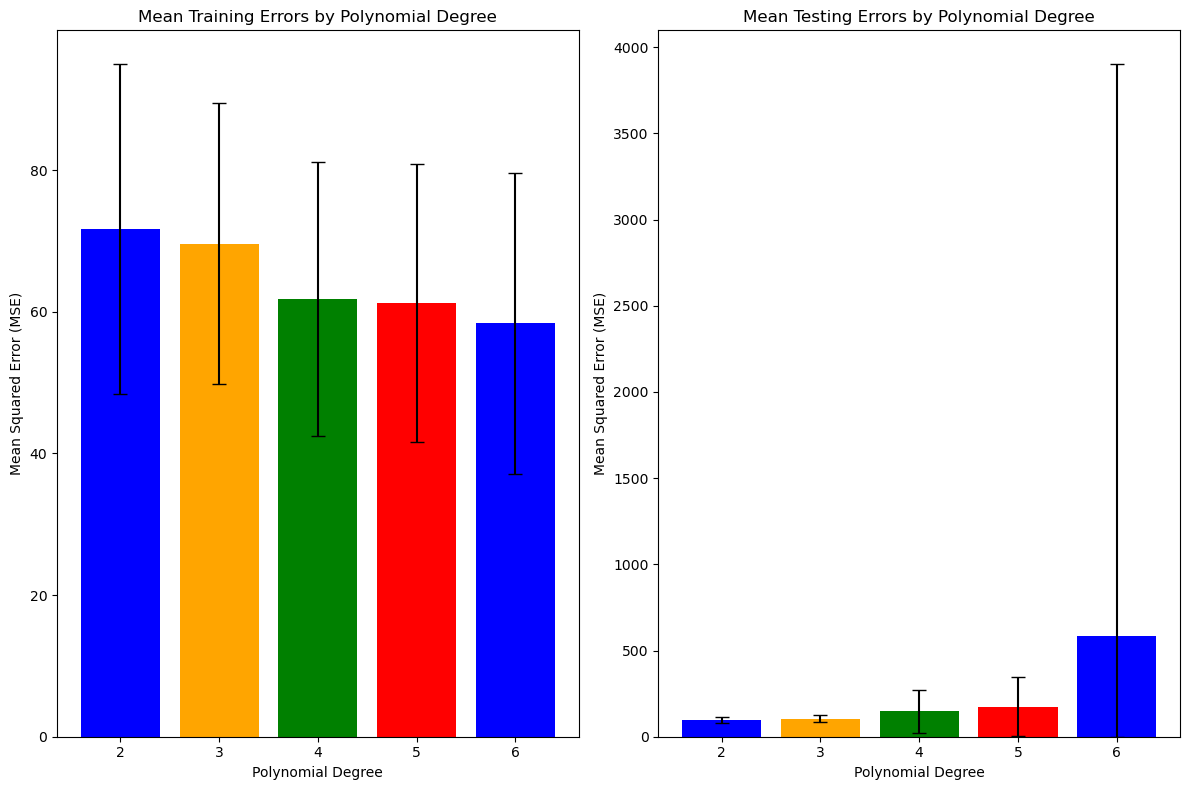

In [20]:
degrees = [2, 3, 4, 5, 6]  # 1st, 2nd, 3rd, and 4th order polynomials

# Initialize dictionaries to store the training and test error means and variances for each degree
error_means_train = {}
error_variances_train = {}
error_means_test = {}
error_variances_test = {}

# Set parameters for sampling and fitting
M = 20  # Number of samples to use
K = 100  # Number of iterations

# Loop through each polynomial degree
for N in degrees:
    
    # Perform the iterative fitting process for the current polynomial degree
    errors_train, errors_test, _, error_mean_train, error_variance_train, error_mean_test, error_variance_test, _, _, _ = iterate_fit(x_range, y_noisy, M, N, K)
    
    # Store the results for training and test sets
    error_means_train[N] = error_mean_train
    error_variances_train[N] = error_variance_train
    error_means_test[N] = error_mean_test
    error_variances_test[N] = error_variance_test
    

# Data preparation
mean_training_errors = [error_means_train[d] for d in degrees]
mean_testing_errors = [error_means_test[d] for d in degrees]
training_error_bars = prepare_error_bars(mean_training_errors, [error_variances_train[d] for d in degrees])
testing_error_bars = prepare_error_bars(mean_testing_errors, [error_variances_test[d] for d in degrees])

colors = ['blue', 'orange', 'green', 'red']

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Plot training errors
axes[0].bar(degrees, mean_training_errors, color=colors, yerr=training_error_bars, capsize=5)
axes[0].set_xticks(degrees)
axes[0].set_title('Mean Training Errors by Polynomial Degree')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('Mean Squared Error (MSE)')

# Plot testing errors
axes[1].bar(degrees, mean_testing_errors, color=colors, yerr=testing_error_bars, capsize=5)
axes[1].set_xticks(degrees)
axes[1].set_title('Mean Testing Errors by Polynomial Degree')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Mean Squared Error (MSE)')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
#Write your reflections here...
#1. the training mse lowers the higher the complexity, but we see the opposite for test mse. 
#   This is because we can better fit any training data to a higher complexity polynomial (it's more flexible), 
#   but then the model is overfit and performs badly on unseen data. 
#   It only catches the noise, not the underlying function. 
#2. The test mse is similar for 2nd and 3rd order, but on the 4th order polynomial, I would say we enter overfitting the model. 
#   The test mse range almost becomes twice as big as the earlier complexities. 
#   The underlying model is a 2nd order polynomial, so it makes sense that increasing complexity leads to overfitting.
#3. The model parameters change based on the complexity. It introduces more model parameters, and they also change the more flexibly fit to the training data points


---
**Task 6 (hard): Model parameters👩‍💻💡📽️**
1. Run the cell below to fit a 5th-order polynomial to the data and visualize the covariance and correlation matrices of the model parameters. 
2. Answer the following questions:    
    - Which pairs of coefficients show high levels of covariance/correlation? 
    - What does the variance of the model parameters say about the performance? 
    - Could this suggest that some coefficients remain relatively stable across different samples?
    - What does the covariance of the model parameters reveal about the performance of the model? 
    - What does this reveal about model stability? 
    - Could this indicate overfitting or sensitivity to changes in the dataset?
    - What does the correlations between coefficients say about the redundancy of model parameters? 
    - Which model parameters contribute very little to the overall model?
    - What is the difference between the covariance and correlation when analyzing the data?




---

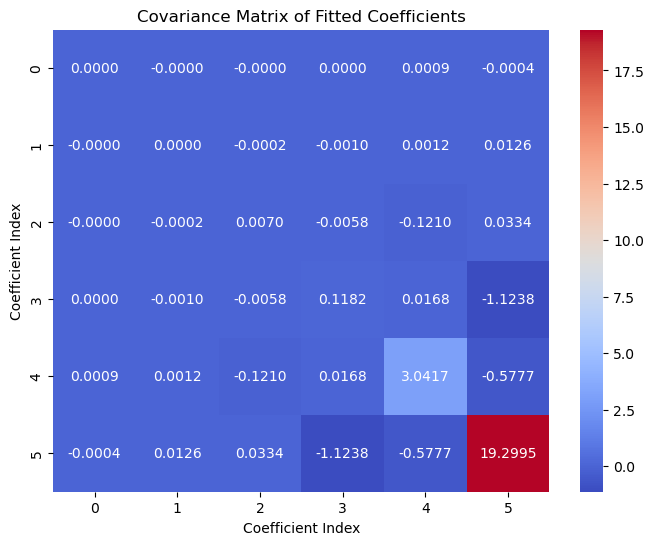

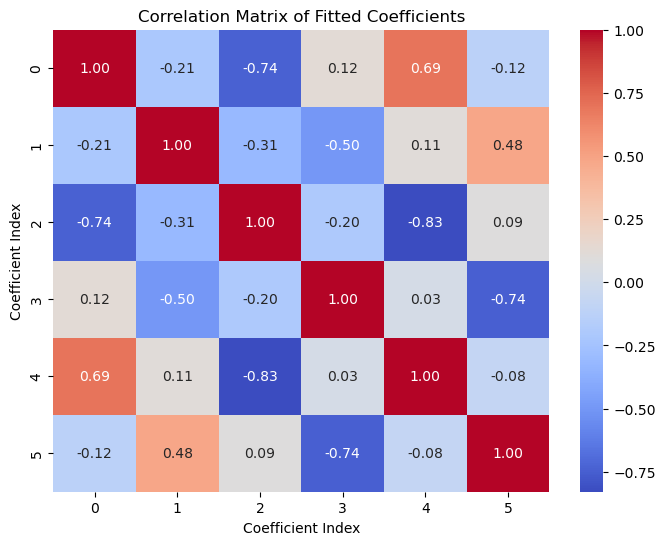

In [24]:
# Set parameters for sampling and fitting
M = 20  # Number of samples to use
K = 100  # Number of iterations
N = 5
errors_train, errors_test, coeffs_array, error_mean_train, error_variance_train, error_mean_test, error_variance_test, coeffs_mean, coeffs_covariance, coeffs_correlation = iterate_fit(x_range, y_noisy, M, N, K)

# Plot the covariance matrix of the fitted polynomial coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coeffs_covariance, annot=True, fmt='.4f', cmap='coolwarm', cbar=True)
plt.title('Covariance Matrix of Fitted Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Index')
plt.show()

# Plot the covariance matrix of the fitted polynomial coefficients
plt.figure(figsize=(8, 6))
sns.heatmap(coeffs_correlation, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Fitted Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Index')
plt.show()

In [0]:
#Write your reflections here...
# Which pairs of coefficients show high levels of covariance/correlation?
#   3+5, 2+4, 0+2, 0+4

# What does the variance of the model parameters say about the performance? 
#   We get a low variance of most coefficients except some variance of 4 and a high variance of 5. 
#   The high variance of the last coefficients show that they change a lot depending on the selected training data. 
#   So it can tell us that it overfits to the data. 

# Could this suggest that some coefficients remain relatively stable across different samples?
#   yes, the first 3-4 coefficients remain pretty much the same, no matter the data. 

# What does the covariance of the model parameters reveal about the performance of the model?
#   Most of the covariances are small, so we might not see a big relation between the coefficients. 
#   The last coefficients have negative covariance, so if some coefficient increases, the other decreases. 
#   The variance of these suggest this depends on the training data chosen. 

# What does this reveal about model stability? 
#   It suggests the model is unstable, as it finds different coefficients and they depend on each other when fitting to a 5th order polynomial. 

# Could this indicate overfitting or sensitivity to changes in the dataset?
#   Both, because the complexity is so high, it overfits to the data and becomes sensitive to what the training data is. 

# What does the correlations between coefficients say about the redundancy of model parameters? 
#   
# Which model parameters contribute very little to the overall model?

# What is the difference between the covariance and correlation when analyzing the data?